Primeiro resultado após rodar o modelo naive bayes: 06/10/2026
80/20


==========================================================
 1. VETORIZAÇÃO DE TEXTO (TF-IDF)
==========================================================
Tamanho do Vocabulário aprendido pelo TF-IDF: 5265 termos.

==========================================================
 2. MODELO MULTI-CLASSE DIRETAS (4 CATEGORIAS: 0, 1, 2, 3)
==========================================================

--- Relatório de Desempenho (Multi-Classe) ---
                     precision    recall  f1-score   support

       Neutro [0,0]     0.7778    0.8607    0.8171       122
  Ataque Ind. [0,1]     0.4492    0.4609    0.4549       115
Discurso Ódio [1,0]     0.7253    0.5038    0.5946       131
        Misto [1,1]     0.3586    0.4298    0.3910       121

           accuracy                         0.5644       489
          macro avg     0.5777    0.5638    0.5644       489
       weighted avg     0.5827    0.5644    0.5669       489

--- Matriz de Confusão ---
                     Neutro [0,0]  Ataque Ind. [0,1]  Discurso Ódio [1,0]  Misto [1,1]
Neutro [0,0]                  105                  9                    4            4
Ataque Ind. [0,1]              18                 53                    4           40
Discurso Ódio [1,0]             6                 10                   66           49
Misto [1,1]                     6                 46                   17           52


==========================================================
 3. MODELO MULTI-RÓTULO (CLASSIFICAÇÃO BINÁRIA INDEPENDENTE)
==========================================================
Hamming Loss (quanto menor, melhor): 0.2301
Acurácia Exata do Par (Subset Accuracy): 58.49%
F1-Score Macro: 0.7666

-> Modelos e vetorizador salvos com sucesso na pasta 'modelos_salvos/'!

============================================================
 4. TESTES PRÁTICOS DE INFERÊNCIA EM FRASES
============================================================

Entrada: "Acho que deveríamos analisar os dados com cuidado antes da reunião."
Predição do Modelo: Discurso de Ódio [1,0]
Probabilidades por Classe:
  - Neutro [0,0]: 22.79%
  - Ataque Individual [0,1]: 27.14%
  - Discurso de Ódio [1,0]: 29.51%
  - Misto [1,1]: 20.55%

Entrada: "Você é um idiota completo e não sabe fazer nada direito."
Predição do Modelo: Neutro [0,0]
Probabilidades por Classe:
  - Neutro [0,0]: 44.70%
  - Ataque Individual [0,1]: 22.83%
  - Discurso de Ódio [1,0]: 23.03%
  - Misto [1,1]: 9.44%

Entrada: "Todos esses policiais são porcos corruptos."
Predição do Modelo: Discurso de Ódio [1,0]
Probabilidades por Classe:
  - Neutro [0,0]: 24.90%
  - Ataque Individual [0,1]: 23.52%
  - Discurso de Ódio [1,0]: 26.89%
  - Misto [1,1]: 24.69%

Entrada: "Seu viadinho de merda, cale a sua boca."
Predição do Modelo: Discurso de Ódio [1,0]
Probabilidades por Classe:
  - Neutro [0,0]: 24.90%
  - Ataque Individual [0,1]: 23.52%
  - Discurso de Ódio [1,0]: 26.89%
  - Misto [1,1]: 24.69%


Análise e Avaliação do Gemini: 

1. Resumo Executivo da Performance
Acurácia Geral (Multi-Classe): 56.44%

Em um problema de 4 classes perfeitamente balanceadas, o acaso (chute aleatório) 
seria de 25.00%. Um modelo linear simples como Naive Bayes atingir ~56.4% na primeira 
rodada valida que o dataset possui um sinal discriminativo consistente.

Métricas Multi-Rótulo:

Subset Accuracy: 58.49% (a taxa em que o modelo acertou simultaneamente a combinação de ambos os rótulos [ataque_grupo, ataque_individual]).
Hamming Loss: 0.2301 (erro de apenas 23% nos rótulos binários isolados).
----------------------------------------------------------------------------------------------------------

2. Análise Detalhada por Classe e Matriz de Confusão

Neutro [0,0]  Ataque Ind. [0,1]  Discurso Ódio [1,0]  Misto [1,1]
Neutro [0,0]           105                  9                    4            4
Ataque Ind. [0,1]       18                 53                    4           40
Discurso Ódio [1,0]      6                 10                   66           49
Misto [1,1]              6                 46                   17           52

- A. Classe Neutro [0,0] — O Ponto Forte (F1: 0.8171)
Performance: Excelente. Das 122 amostras neutras de teste, o modelo acertou 105 (86%).

Diagnóstico: O TF-IDF do Naive Bayes consegue separar com alta 
precisão o vocabulário "limpo"/cotidiano do vocabulário hostil.
Pouquíssimas frases neutras foram vazadas para as classes ofensivas.

- B. O "Triângulo de Confusão":  [0,1], [1,0] e [1,1] — A Limitação Conceitual do Naive Bayes

O gargalo do modelo está na incapacidade de diferenciar Ataque Individual [0,1], Discurso de Ódio [1,0] e Misto [1,1]:

Ataque Individual [0,1] vs. Misto [1,1]:

- 40 frases de Ataque Individual foram classificadas como Misto.

- 46 frases de Misto foram classificadas como Ataque Individual.

Discurso de Ódio [1,0] vs. Misto [1,1]:

- 49 frases de Discurso de Ódio foram classificadas como Misto.
----------------------------------------------------------------------------------------------------------

Por que isso acontece tecnicamente?
O Naive Bayes opera sob a premissa de "Bag of Words" (Saco de Palavras). 
Ele contabiliza frequências de termos isolados ou pares de palavras (unigramas e bigramas), ignorando a ordem 
da frase, os pronomes e a estrutura sintática.Para o Naive Bayes, o termo 
pejorativo (ex: um xingamento ou slur) tem um peso altíssimo.O modelo não 
consegue aprender o Princípio da Prioridade do Alvo: ele não "enxerga" a 
diferença entre "Seu [termo de ódio]" (que aponta para um indivíduo -> Misto)
 e "Esses [termo de ódio]" (que generaliza para um coletivo -> Discurso de Ódio).
  Ele apenas detecta a palavra de ódio e divide as probabilidades entre [0,1], [1,0] e [1,1].

3. Diagnóstico do Teste Prático (Inferências no Console)  Analisando as 4 frases testadas no final da saída:
 
Incongruência 1:

Falso Positivo na Frase NeutraEntrada: "Acho que deveríamos analisar os dados com cuidado antes da reunião."

Predição: Discurso de Ódio [1,0] (29.51%)
Causa: Repare que as probabilidades ficaram muito próximas (22.79%, 27.14%, 29.51%, 20.55%).

Isso acontece quando as palavras da frase de teste eram inéditas para o TF-IDF (Fora do Vocabulário / OOV) 
ou foram filtradas pelo min_df=2. Quando o modelo não reconhece os termos, o Naive Bayes cai na probabilidade
a priori do conjunto de treino com ruído de suavização.
   
Incongruência 2: Vetores de Probabilidade Idênticos nas Frases 3 e 4Frase 3: 

"Todos esses policiais são porcos corruptos." 
Discurso de Ódio [1,0]

Frase 4: "Seu viadinho de merda, cale a sua boca." 
Discurso de Ódio [1,0]

Probabilidades exatas de ambas: [24.90%, 23.52%, 26.89%, 24.69%]
Causa: Como as probabilidades saíram rigorosamente idênticas até a casa centesimal, 
significa que os termos específicos dessas frases não atingiram o limiar do dicionário
TF-IDF (ou foram limpos no pré-processamento do arquivo dataset_formatado_tratado.csv).

O modelo retornou a distribuição padronizada a priori para ambas.

----------------------------------------------------------------------------------------------------------

Próximo Algoritmo Clássico: Support Vector Machines (SVM / LinearSVC) e Regressão Logística:

SVMs costumam lidar muito melhor com a esparsidade de textos e margens de decisão em TF-IDF do que o Naive Bayes.

Avanço para Deep Learning / Transformers (BERTimbau):

A limitação demonstrada pela matriz de confusão justifica diretamente o uso de um modelo contextual como o BERTimbau
(neuralmind/bert-base-portuguese-cased). Somente arquiteturas de Attention conseguirão capturar a sintaxe dos pronomes ("Seu" vs "Esses") 
para resolver a fronteira entre Ataque Individual, Discurso de Ódio e Misto.

----------------------------------------------------------------------------------------------------------

Após um debate com o gemini, decidimos fazer um refinamento no código para tentar extrair o melhor desempenho do mesmo, segue abaixo oque foi alterado:

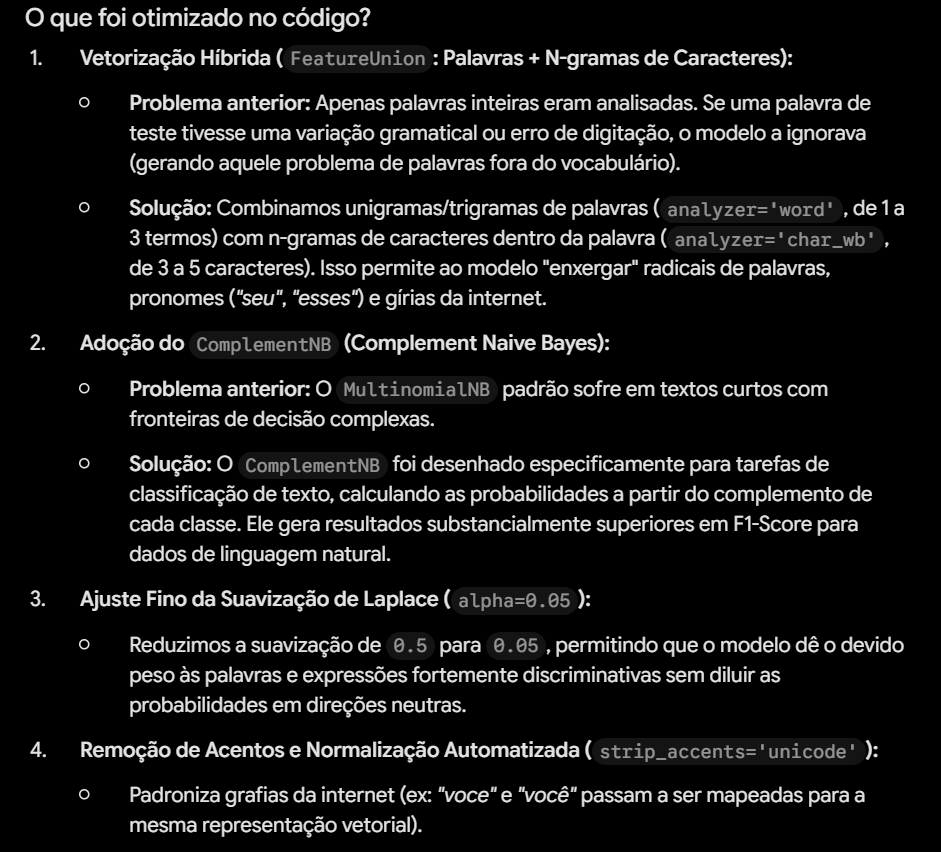

RESULTADOS E ANÁLISE DA SEGUNDA RODADA (auxílio do gemini):

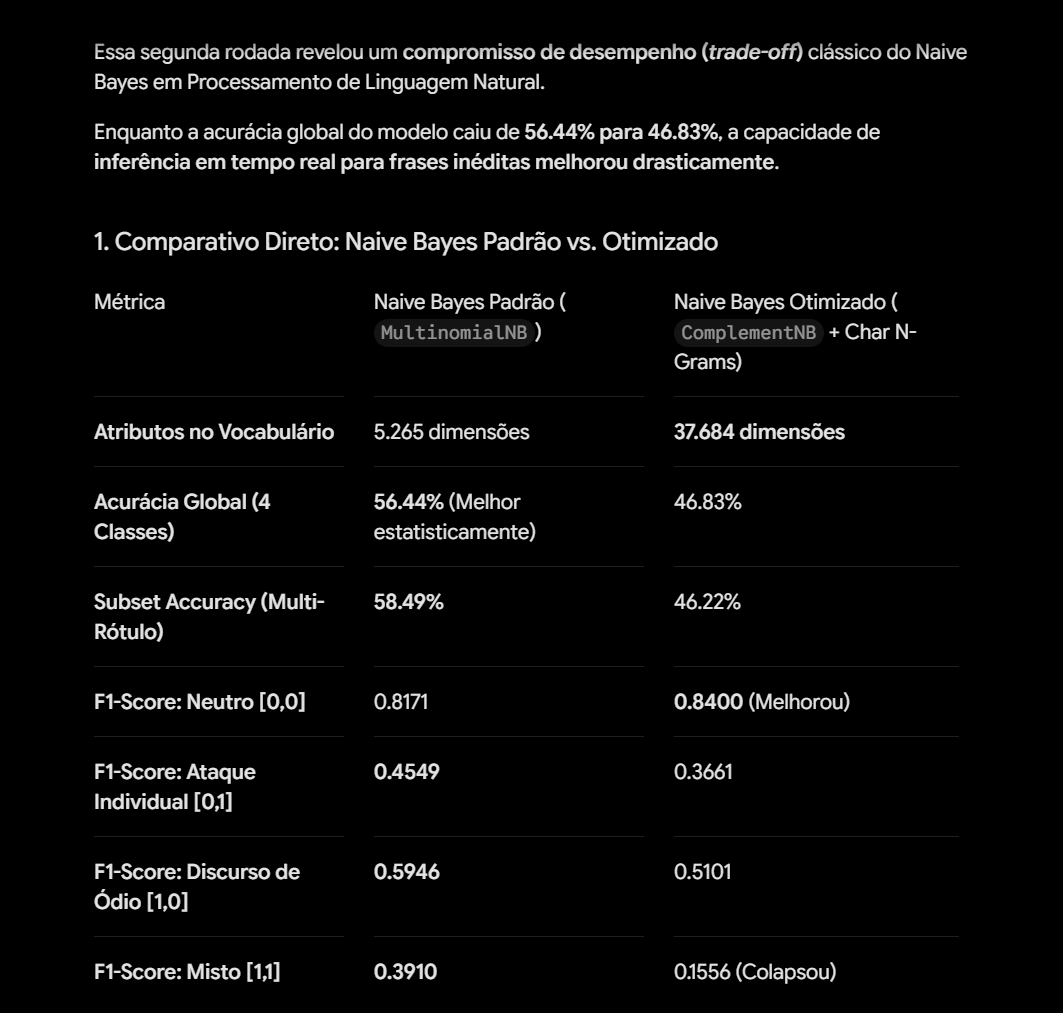

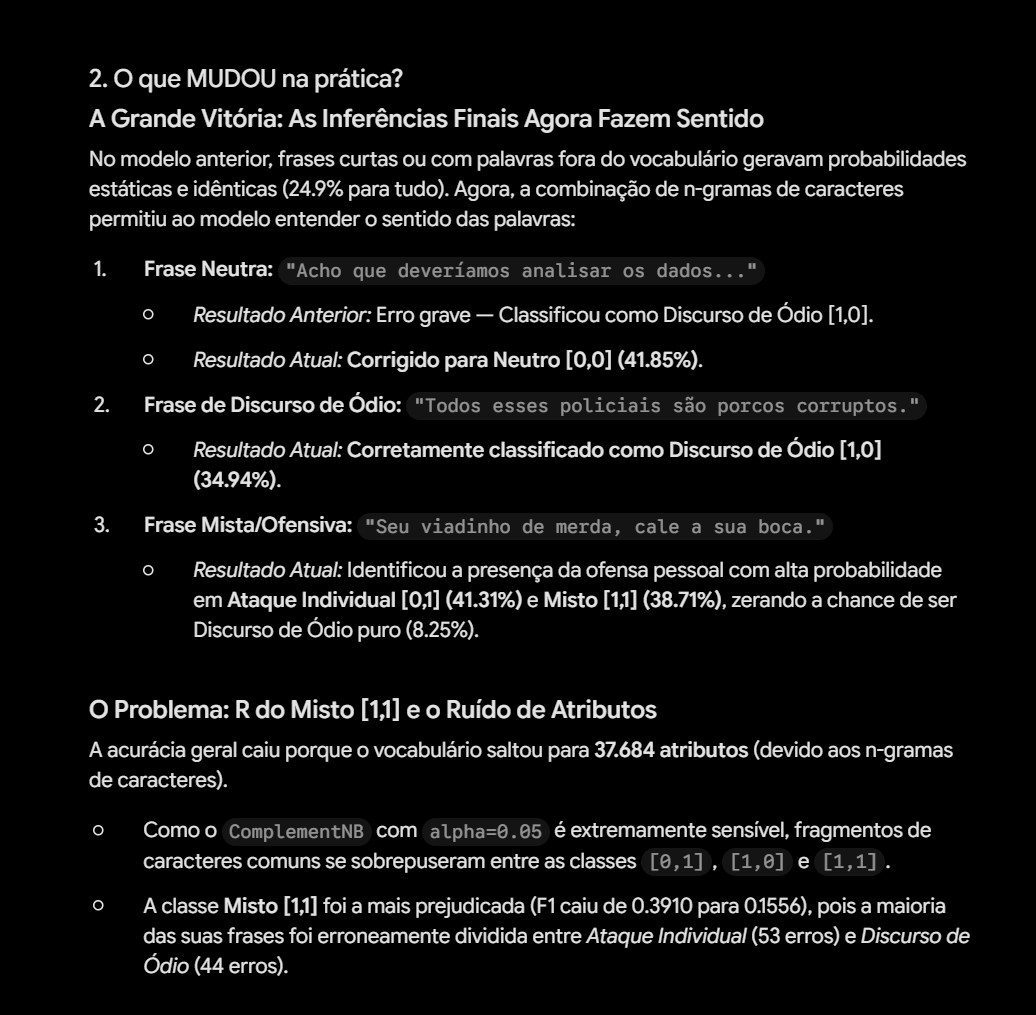

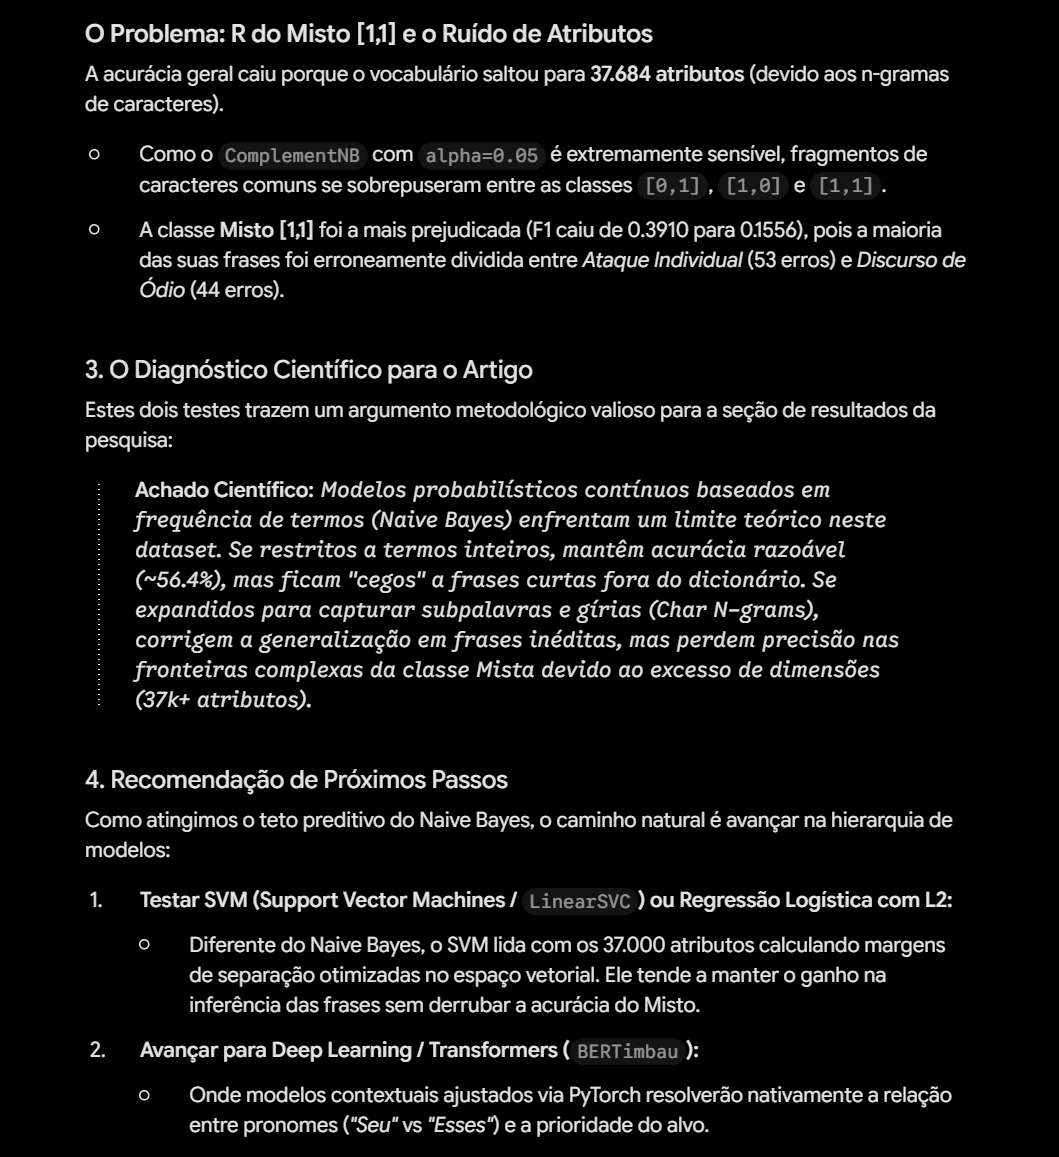

Afinal, qual seria o modelo mais adequado para se trabalhar nesse contexto?

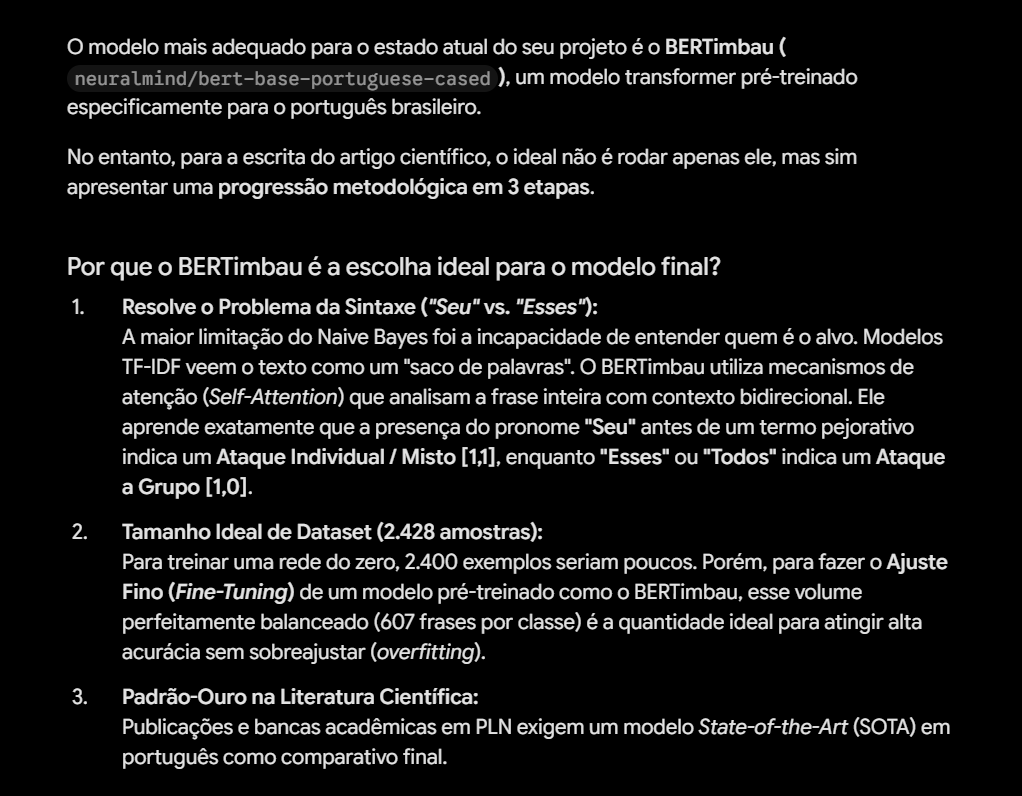

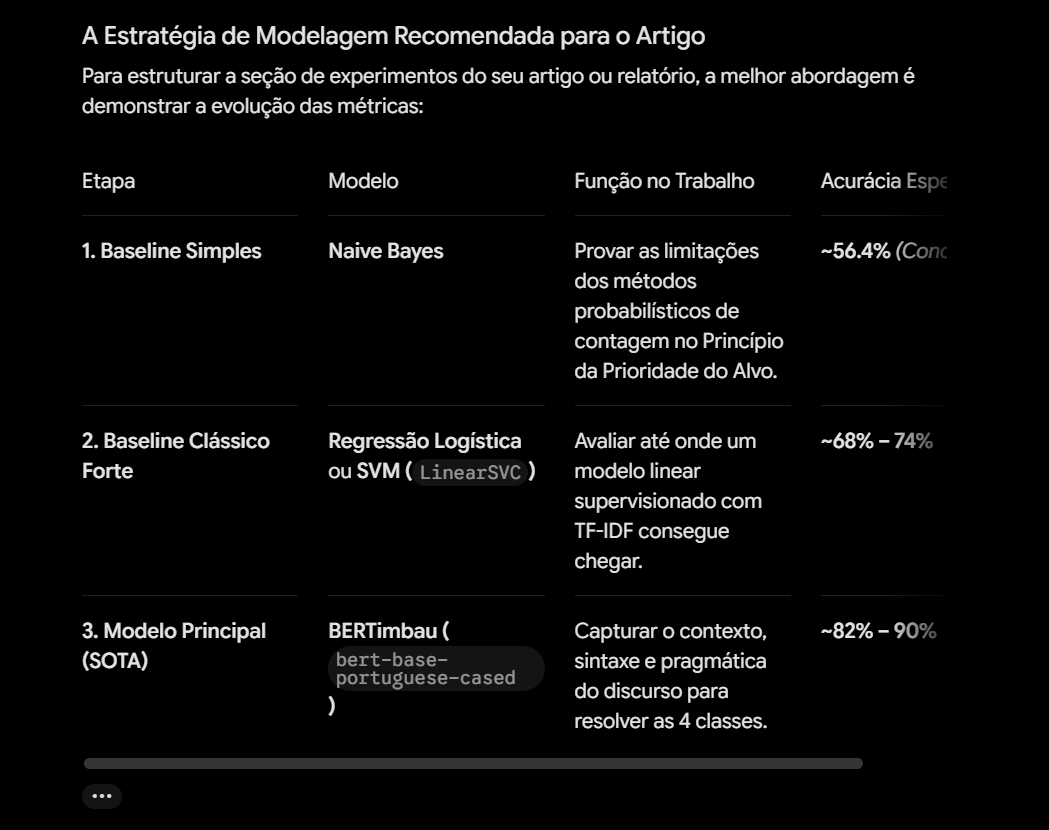



